# 1.Importação das bibliotecas

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
 
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# 2. carregamento do dataset

In [8]:
#carregando o dataset
df = pd.read_csv('/kaggle/input/datasets/uciml/breast-cancer-wisconsin-data/data.csv')

#Mostra as 5 ptimeiras linhas 
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


# 3.Conhecendo os dados 

In [9]:
print("linhas e colunas:", df.shape) 

#informações sobre colunas e tipos de dados 
df.info()

linhas e colunas: (569, 33)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14

# 4.Verificação de valores ausentes 

In [10]:
#Verificar quantos valores ausentes existem em cada coluna
df.isnull().sum()

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

# 5. Limpeza dos dados 

In [11]:
#Remove o identificador e a coluna vazia 
df = df.drop(columns=["id", "Unnamed: 32"])

df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


# 6. Distribuição dos diagnóstico

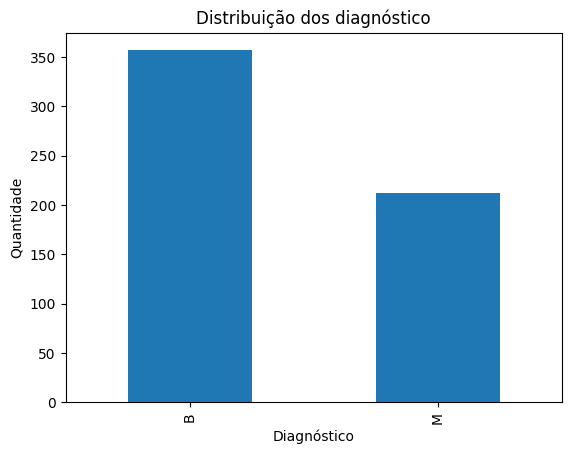

In [12]:
# Quantidade de casos benignos e malignos
df["diagnosis"].value_counts () .plot(kind="bar")

plt.title("Distribuição dos diagnóstico")
plt.xlabel("Diagnóstico")
plt.ylabel("Quantidade")
plt.show()

# 7. Transfomação de variável alvo

In [13]:
# Converte as classes para valores numéricos
df['diagnosis'] = df['diagnosis'].map({
'B': 0,
'M': 1
})

df['diagnosis'].value_counts()
 

diagnosis
0    357
1    212
Name: count, dtype: int64

# 8. Separação entre X e Y

In [14]:
# X = características utilizadas para realizar a previsão
X = df.drop(columns='diagnosis')

# y = resposta que queremos prever
y = df['diagnosis']

print("X:", X.shape)
print("y:", y.shape)

X: (569, 30)
y: (569,)


# 9. Separação em treino e teste 

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
   X,
   y,
   test_size=0.20,
   random_state=42,
   stratify=y  # Mantém a proporção de benignos e malignos
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

Treino: (455, 30)
Teste: (114, 30)


# 10. Padronização dos dados 

In [16]:
# Cria o padronizador
scaler = StandardScaler()

# Aprende a escala apenas com os dados de treino
X_train_scaled = scaler.fit_transform(X_train)

# Aplica a mesma transformação nos dados de teste
X_test_scaled = scaler.transform(X_test)

# 11. SVM com Kernel Linear

In [17]:
# Criando o modelo SVM Linear
svm_linear = SVC(
   kernel='linear',
   C=1.0
)
# Treinamento
svm_linear.fit(X_train_scaled, y_train)
# Previsões
y_pred_linear = svm_linear.predict(X_test_scaled)

In [18]:
acc_linear = accuracy_score(y_test, y_pred_linear)
print("Acurácia SVM Linear:", round(acc_linear, 4))
print("\nRelatório de classificação:")
print(classification_report(
   y_test,
   y_pred_linear,
   target_names=['Benigno', 'Maligno']
))

Acurácia SVM Linear: 0.9649

Relatório de classificação:
              precision    recall  f1-score   support

     Benigno       0.95      1.00      0.97        72
     Maligno       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



# 12. Matriz de confusão - Linear

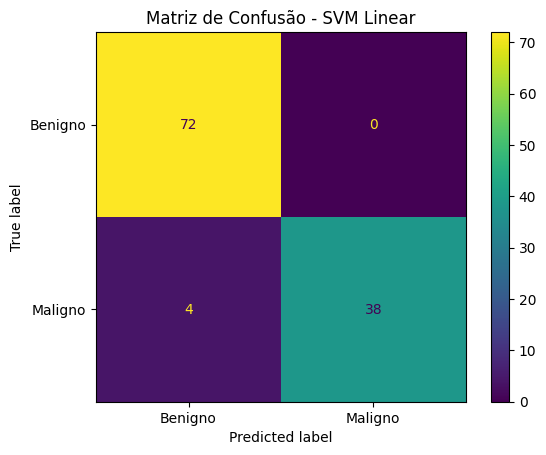

In [19]:
cm_linear = confusion_matrix(y_test, y_pred_linear)
disp = ConfusionMatrixDisplay(
   confusion_matrix=cm_linear,
   display_labels=['Benigno', 'Maligno']
)
disp.plot()
plt.title('Matriz de Confusão - SVM Linear')
plt.show()

# 13. Validação cruzada - Linear 

In [20]:
pipeline_linear = Pipeline([
   ('scaler', StandardScaler()),
   ('svm', SVC(kernel='linear', C=1.0))
])
# Validação cruzada com 5 partes
scores_linear = cross_val_score(
   pipeline_linear,
   X,
   y,
   cv=5
)
print("Resultados:", scores_linear)
print("Média:", scores_linear.mean())

Resultados: [0.96491228 0.98245614 0.96491228 0.96491228 0.98230088]
Média: 0.9718987734823784


# 14. SVM com Kernel RBF

In [21]:
# Criando o modelo SVM com kernel RBF
svm_rbf = SVC(
   kernel='rbf',
   C=1.0,
   gamma='scale'
)

# Treinamento
svm_rbf.fit(X_train_scaled, y_train)

# Previsões
y_pred_rbf = svm_rbf.predict(X_test_scaled)

# 15. Avaliação do SVM RBF

In [22]:
acc_rbf = accuracy_score(y_test, y_pred_rbf)
print("Acurácia SVM RBF:", round(acc_rbf, 4))
print("\nRelatório de classificação:")
print(classification_report(
   y_test,
   y_pred_rbf,
   target_names=['Benigno', 'Maligno']
))

Acurácia SVM RBF: 0.9737

Relatório de classificação:
              precision    recall  f1-score   support

     Benigno       0.96      1.00      0.98        72
     Maligno       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



# 16. Matriz de confusão - RBF

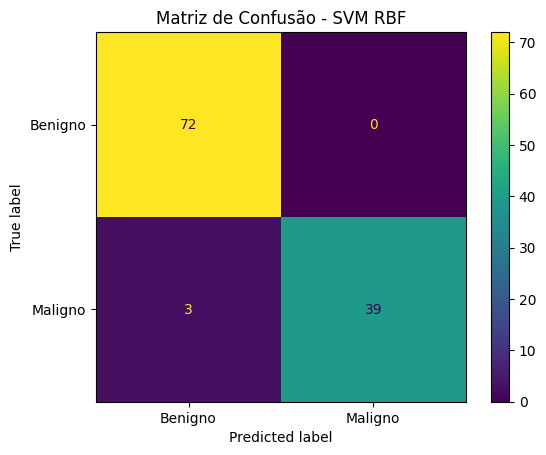

In [23]:
cm_rbf = confusion_matrix(y_test, y_pred_rbf)
disp = ConfusionMatrixDisplay(
   confusion_matrix=cm_rbf,
   display_labels=['Benigno', 'Maligno']
)
disp.plot()
plt.title('Matriz de Confusão - SVM RBF')
plt.show()

# 17. Validação cruzada - RBF

In [24]:
pipeline_rbf = Pipeline([
   ('scaler', StandardScaler()),
   ('svm', SVC(kernel='rbf', C=1.0, gamma='scale'))
])
scores_rbf = cross_val_score(
   pipeline_rbf,
   X,
   y,
   cv=5
)
print("Resultados:", scores_rbf)
print("Média:", scores_rbf.mean())

Resultados: [0.97368421 0.95614035 1.         0.96491228 0.97345133]
Média: 0.9736376339077782


# 18. Comparação dos modelos

In [25]:
comparacao = pd.DataFrame({
   'Modelo': ['SVM Linear', 'SVM RBF'],
   'Acurácia Teste': [
       acc_linear,
       acc_rbf
   ],
   'Média Validação Cruzada': [
       scores_linear.mean(),
       scores_rbf.mean()
   ]
})
comparacao

,Modelo,Acurácia Teste,Média Validação Cruzada
0,SVM Linear,0.964912,0.971899
1,SVM RBF,0.973684,0.973638


# 19. Ajuste de C e gamma 

In [26]:
# Pipeline evita problemas na padronização durante a busca
pipeline = Pipeline([
   ('scaler', StandardScaler()),
   ('svm', SVC())
])
parametros = [
   {
       'svm__kernel': ['linear'],
       'svm__C': [0.1, 1, 10]
   },
   {
       'svm__kernel': ['rbf'],
       'svm__C': [0.1, 1, 10],
       'svm__gamma': ['scale', 0.01, 0.1]
   }
]

# Testa diferentes combinações automaticamente
grid = GridSearchCV(
   pipeline,
   parametros,
   cv=5,
   scoring='accuracy'
)
grid.fit(X_train, y_train) 

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('svm', SVC())]),
             param_grid=[{'svm__C': [0.1, 1, 10], 'svm__kernel': ['linear']},
                         {'svm__C': [0.1, 1, 10],
                          'svm__gamma': ['scale', 0.01, 0.1],
                          'svm__kernel': ['rbf']}],
             scoring='accuracy')

# 20. melhores parametros encontrados

In [27]:
print("melhores parâmetros:")
print(grid.best_params_)

print("melhor resultado:")
print(grid.best_score_)

melhores parâmetros:
{'svm__C': 1, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
melhor resultado:
0.9736263736263737


# 21. avalição do melhor modelo

In [28]:
# O GridSearch já guarda o melhor modelo encontrado
melhor_modelo = grid.best_estimator_
 
y_pred_melhor = melhor_modelo.predict(X_test)
 
print("Acurácia:", accuracy_score(y_test, y_pred_melhor))
 
print("\nRelatório de classificação:")
print(classification_report(
    y_test,
    y_pred_melhor,
    target_names=['Benigno', 'Maligno']
))

Acurácia: 0.9736842105263158

Relatório de classificação:
              precision    recall  f1-score   support

     Benigno       0.96      1.00      0.98        72
     Maligno       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



# 22. Matriz de confusão do melhor modelo

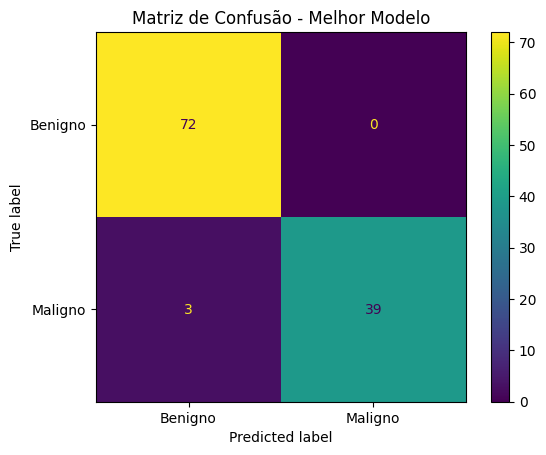

In [29]:
cm = confusion_matrix(y_test, y_pred_melhor)
 
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Benigno', 'Maligno']
)
 
disp.plot()
plt.title('Matriz de Confusão - Melhor Modelo')
plt.show()